In [ ]:
from pathlib import Path
import xarray as xr
import utils
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap
from sklearn.datasets import load_digits
import re
import json
import pickle
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as CFeature
import random
from scipy.stats import bootstrap
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import matplotlib.colors as mcolors
import add_best_track

## Start in code cell 7 if CombinedDataset.nc is already created.


Some Additional Filtering that wasn't included in the original data consolidation workflow

In [2]:
def TC_linear_classifier(feature, target):

        if len(np.shape(feature)) == 1:
            feature = feature.reshape(-1,1)
        X_train, X_test, y_train, y_test = train_test_split(feature, target)
        poly_model = make_pipeline(LinearRegression())
        fitted_model = poly_model.fit(X_train, y_train)
        y_pred = fitted_model.predict(X_test)
        resids = y_pred - y_test
        standard_error = np.std(resids)/np.sqrt(len(y_pred))

        return {'RMSE': np.sqrt(mean_squared_error(y_test,y_pred)), 
                'Coefficient of Determination': fitted_model.score(X_test, y_test),
                'Standard Error': standard_error}

In [3]:

# Loading and combining the 3 TC Field datasets

ds1 = xr.open_dataset('Model_Data/CompleteData/Semester2_TC_Fields_pt1.nc')
ds2 = xr.open_dataset('Model_Data/CompleteData/Semester2_TC_Fields_pt2.nc')
ds3 = xr.open_dataset('Model_Data/CompleteData/Semester2_TC_Fields_pt3.nc')

ds = xr.concat((ds1, ds2, ds3), dim = 'frame_number')


In [4]:
# Checking for NA's
ds_cleaned = ds.dropna(dim = 'frame_number', how = 'any')

#Selecting only hfsa runs
hfsa_index = ['hfsa' in link for link in ds['frame_link'].values]
ds_cleaned = ds_cleaned.sel(frame_number = hfsa_index, drop = True)
# Limiting frames to tropical storm strength or stronger (17 m/s or stronger)
ds_cleaned = ds_cleaned.where(ds_cleaned['max_wind'] >= 17, drop = True)

# Only using storms in the Northern Hemisphere
ds_final = ds_cleaned.where(ds_cleaned['center_lat'] > 0, drop = True)
# ds_cleaned = ds_cleaned.dropna(dim = 'frame_number', how = 'any')


In [5]:
fl_wind_max = np.max(np.sqrt(ds_final['rad_wind'].isel(levels = 1).values ** 2 + ds_final['az_wind'].isel(levels = 1).values ** 2), axis = (1,2))
wind_change = ds_final['max_wind_24hrs'].isel(levels = 0).values - ds_final['max_wind'].isel(levels = 0).values

storm_category = []

for wind in ds_final['max_wind'].isel(levels = 0).values:
        if   wind < 33:
                storm_category.append(0)
        elif 33 <= wind < 43:
                storm_category.append(1)
        elif 43 <= wind < 50:
                storm_category.append(2)
        elif 50 <= wind < 58:
                storm_category.append(3)
        elif 58 <= wind < 70:
                storm_category.append(4)
        elif 70 <= wind:
                storm_category.append(5)
storm_category = np.array(storm_category)

TC_baseline = TC_linear_classifier(np.array([ds_final['center_pressure'].isel(levels = 0).values, fl_wind_max]).T, ds_final['max_wind'].isel(levels = 0).values)

# number_of_reps = 20
# avg_RMSE = []      
# avg_R2 = []     
# avg_SE = []       

# for i in np.arange(number_of_reps):
#         RMSE = []
#         R2 = []
#         SE = []
#         for category in np.unique(storm_category):
#                 # feature = fl_wind_max[storm_category == category]
#                 feature = np.array([ds_final['center_pressure'].isel(levels = 0).values[storm_category == category], fl_wind_max[storm_category == category]])
#                 target = wind_change[storm_category == category]
#                 result = TC_linear_classifier(feature.T, target)
#                 RMSE.append(result['RMSE'])
#                 R2.append(result['Coefficient of Determination'])
#                 SE.append(result['Standard Error'])
#         avg_RMSE.append(np.array(RMSE))
#         avg_R2.append(np.array(R2))
#         avg_SE.append(np.array(SE))
        
# avg_RMSE = np.mean(avg_RMSE, axis =0) 
# avg_R2 = np.mean(avg_R2, axis =0) 
# avg_SE = np.mean(avg_SE, axis =0) 

In [7]:
class TC_embedding():
    def __init__(self, ds: xr.dataset, embedding_fields: list):

        # Initializing desired fields
        self.dataset = ds
        self.fields = {}
        self.normal_data = {}
        for name in embedding_fields:
            self.fields[f'{name}'] = self.dataset[name].isel(levels = 1)

        # Generating some statistics

        self.mslp = self.dataset['center_pressure'].isel(levels = 0).values
        self.max_winds = self.dataset['max_wind'].isel(levels = 0).values
        self.pressure_change = self.dataset['center_pressure_24hrs'].isel(levels = 0).values - self.mslp
        self.wind_change = self.dataset['max_wind_24hrs'].isel(levels = 0).values - self.max_winds
        self.fl_wind_max = np.max(self.dataset['rad_wind'].isel(levels = 1).values, axis = (1,2))
        self.category = []
        self.embedding = np.zeros((len(self.dataset['frame_number'].values), 2))

        for wind in self.max_winds:
            if   wind < 33:
                self.category.append(0)
            elif 33 <= wind < 43:
                self.category.append(1)
            elif 43 <= wind < 50:
                self.category.append(2)
            elif 50 <= wind < 58:
                self.category.append(3)
            elif 58 <= wind < 70:
                self.category.append(4)
            elif 70 <= wind:
                self.category.append(5)
        

        self.baseline_acc_current = {'classifier': 'Linear regression of minimum central pressure to surface max winds',
                             'Statistics': self.TC_classifier(feature = np.stack((self.mslp, self.fl_wind_max), axis = -1), target = self.max_winds)
                            }
        
        self.baseline_acc_change = {'classifier': 'Linear regression of minimum central pressure to 24 hour intensity change.',
                             'Statistics': self.TC_classifier(feature = np.stack((self.mslp, self.fl_wind_max), axis = -1), target = self.wind_change)
                            }
        
    def TC_classifier(self, feature, target):

        if len(np.shape(feature)) == 1:
            feature = feature.reshape(-1,1)

        X_train, X_test, y_train, y_test = train_test_split(feature, target)
        model = LinearRegression()
        fitted_model = model.fit(X_train, y_train)
        y_pred = fitted_model.predict(X_test)
        resids = y_pred - y_test
        standard_error = np.std(resids)/np.sqrt(len(y_pred))
        return {'RMSE': np.sqrt(mean_squared_error(y_test,y_pred)), 
                'Coefficient of Determination': fitted_model.score(X_test, y_test),
                'Standard Error': standard_error}
        
    def Show_baseline(self):
        print(self.baseline_acc_current)
        print(self.baseline_acc_change)

    def Normalize_data(self, method = 'MinMax'):

        '''
            Methods: 'MinMax', 'Gauss'
        '''
        if   method == 'MinMax':
            

            for key in self.fields.keys():
                self.normal_data[key] = self.minmax_data_normalizer(self.fields[key])
        elif   method == 'Gauss':
                    
        
                    for key in self.fields.keys():
                        self.normal_data[key] = self.standard_data_normalizer(self.fields[key])
            

    def standard_data_normalizer(self, da):
        frame_number, angle, radius = da.shape
        flattened_arrary = da.values.reshape(-1,1)
        scaler = StandardScaler()
        data_normalized_flat = scaler.fit_transform(flattened_arrary)
        data_normalized = data_normalized_flat.reshape(frame_number, angle, radius)

        return data_normalized    
    
    def minmax_data_normalizer(self, da):
        frame_number, angle, radius = da.shape
        flattened_arrary = da.values.reshape(-1,1)
        scaler = MinMaxScaler()
        data_normalized_flat = scaler.fit_transform(flattened_arrary)
        data_normalized = data_normalized_flat.reshape(frame_number, angle, radius)

        return data_normalized

    def Plot_locations(self, shading = None, cmap = 'RdBu'):
        '''
        shadings: 'mslp', 'max_wind', 'max_wind_change', 'px_change', 'categories
        '''

        if shading == 'mslp':
            shading = self.mslp
        elif shading == 'max_wind':
            shading = self.max_winds
        elif shading == 'max_wind_change':
            shading = self.wind_change
        elif shading == 'px_change':
            shading = self.pressure_change
        elif shading == 'categories':
            shading = self.category
        else:
            shading = None

        
        
        lats = self.dataset['center_lat'].isel(levels = 0).values
        lons = self.dataset['center_lon'].isel(levels = 0).values


        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (10,8), subplot_kw = {'projection': ccrs.PlateCarree()})

        im = ax.scatter(lons, lats, transform = ccrs.PlateCarree(), s = 3, c = shading, cmap = cmap)
        ax.add_feature(CFeature.COASTLINE)
        ax.set_title('Storm Locations')
        fig.colorbar(im, location = 'bottom')

    def Plot_strengths(self):

        bin_names = ['Tropical Storms', 'Cat 1', 'Cat 2', 'Cat 3', 'Cat 4', 'Cat 5']

        plt.hist(self.category, rwidth = 0.75)
        plt.xticks([0,1,2,3,4,5], bin_names)
        plt.title('Distribution of Storm Strength within the Dataset')

    def Fit(self, neighbors = 4):

        if self.normal_data:
            num_fields = len(self.normal_data.keys())
            dataset_size = len(self.dataset['frame_number'].values)
            array = []
            first = True
            for field in self.normal_data.keys():
                if first:
                    array = self.normal_data[field].reshape(dataset_size, 720 * 501)
                    first = False
                else:
                    array = np.concat((array, self.normal_data[field].reshape(dataset_size, 720 * 501)), axis = 1)
            embedder = umap.UMAP(n_components = 2, n_neighbors = neighbors, random_state = 12, init = 'pca') 
            return(embedder.fit_transform(array))   
        else:
            dataset_size = len(self.dataset['frame_number'].values)
            num_fields = len(self.fields.keys())
            array = []
            first = True
            for field in self.fields.keys():
                if first:
                    array = self.fields[field].values.reshape(dataset_size, 720 * 501)
                    first = False
                else:
                    array = np.concat((array, self.fields[field].values.reshape(dataset_size, 720 *501)), axis = 1) 

            embedder = umap.UMAP(n_components = 2, n_neighbors = neighbors, random_state = 12, init = 'pca') 
            return(embedder.fit_transform(array))     
        

        

In [27]:
NEIGHBORS = 5
wind_change_bins = [-30,-14,-7, 0, 7, 14,50]
wind_change_colors = [mcolors.CSS4_COLORS.get('red'),
                      mcolors.CSS4_COLORS.get('lightcoral'),
                      mcolors.CSS4_COLORS.get('mistyrose'), 
                      mcolors.CSS4_COLORS.get('lightsteelblue'), 
                      mcolors.CSS4_COLORS.get('royalblue'),
                      mcolors.CSS4_COLORS.get('navy')]
wind_change_cmap = mcolors.ListedColormap(wind_change_colors)
wind_change_norm = mcolors.BoundaryNorm(boundaries=wind_change_bins, ncolors=len(wind_change_colors))
# wind_change_base_cmap = plt.colormaps["RdBu"]
# binned_cmap_wind_change = wind_change_base_cmap.resampled(8)

In [9]:
fields = ['gh', 'rad_wind', 'az_wind', 't']
embed_4 = TC_embedding(ds_final, fields)
embed_4.Normalize_data()
result_4 = embed_4.Fit(neighbors = NEIGHBORS)
result_4_lc = TC_linear_classifier(result_4, ds_final['max_wind'].isel(levels = 0).values)

/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [10]:
fields = ['gh']
embed_gh = TC_embedding(ds_final, fields)
embed_gh.Normalize_data()
result_gh = embed_gh.Fit(neighbors = NEIGHBORS)
result_gh_lc = TC_linear_classifier(result_gh, ds_final['max_wind'].isel(levels = 0).values)

/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [11]:
fields = ['rad_wind', 'az_wind']
embed_winds = TC_embedding(ds_final, fields)
embed_winds.Normalize_data()
result_winds = embed_winds.Fit(neighbors = NEIGHBORS)
result_winds_lc = TC_linear_classifier(result_winds, ds_final['max_wind'].isel(levels = 0).values)

/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
fields = ['gh','rad_wind', 'az_wind']
embed_winds_gh = TC_embedding(ds_final, fields)
embed_winds_gh.Normalize_data()
result_winds_gh = embed_winds_gh.Fit(neighbors = NEIGHBORS)
result_winds_gh_lc = TC_linear_classifier(result_winds_gh, ds_final['max_wind'].isel(levels = 0).values)

/data/keeling/a/ianpark3/miniconda3/envs/ThesisTest/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 0.98, 'TC Embedding | fields: GH, Radial Winds, Azimuthal Winds, Temperature | neighbors: 5 \n TC Wind Classifier RMSE: 9.5')

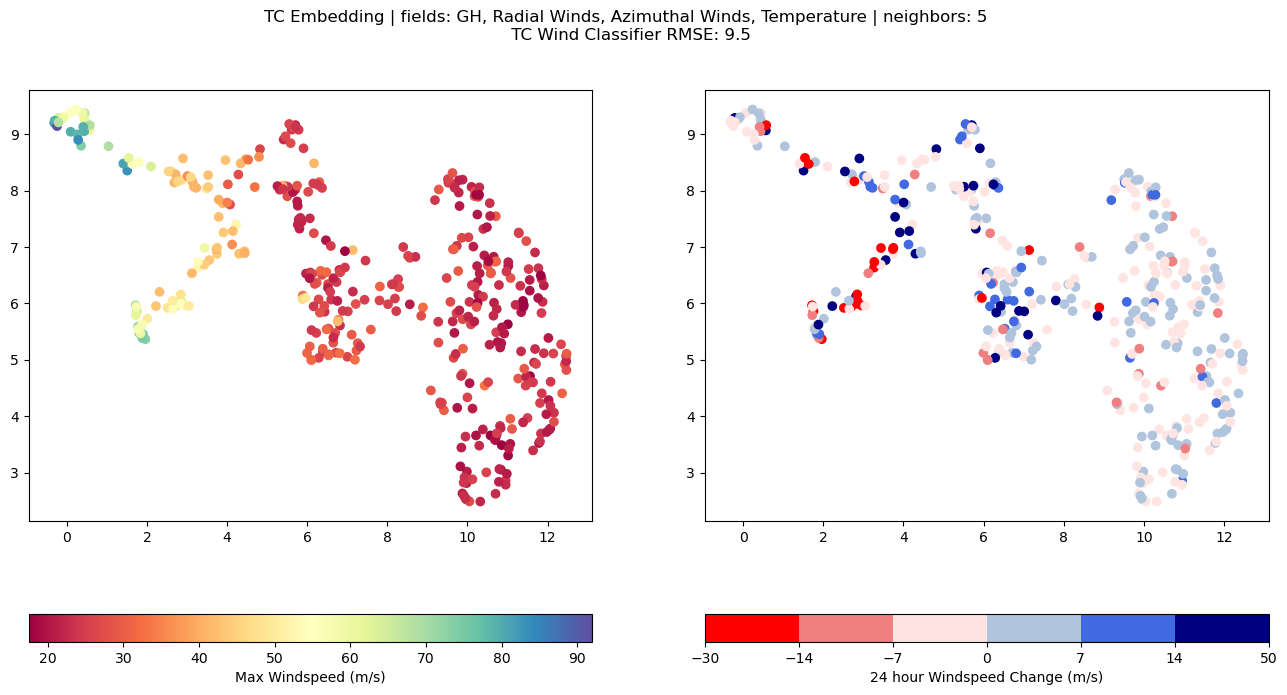

In [28]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (16,8))
im_wind = axs[0].scatter(result_4[:,0], result_4[:,1], c = ds_final["max_wind"].isel(levels = 0).values, cmap = 'Spectral')
im_windchange = axs[1].scatter(result_4[:,0], result_4[:,1], c = wind_change, cmap = wind_change_cmap, norm = wind_change_norm)
fig.colorbar(im_windchange, ax = axs[1], location = "bottom", label = "24 hour Windspeed Change (m/s)")
fig.colorbar(im_wind, ax = axs[0], location = "bottom", label = "Max Windspeed (m/s)")

fig.suptitle(f'TC Embedding | fields: GH, Radial Winds, Azimuthal Winds, Temperature | neighbors: {NEIGHBORS} \n TC Wind Classifier RMSE: {np.round(result_4_lc['RMSE'],2)}')

Text(0.5, 0.98, 'TC Embedding | fields: GH, Radial Winds, Azimuthal Winds | neighbors: 5 \n TC Wind Classifier RMSE: 8.38')

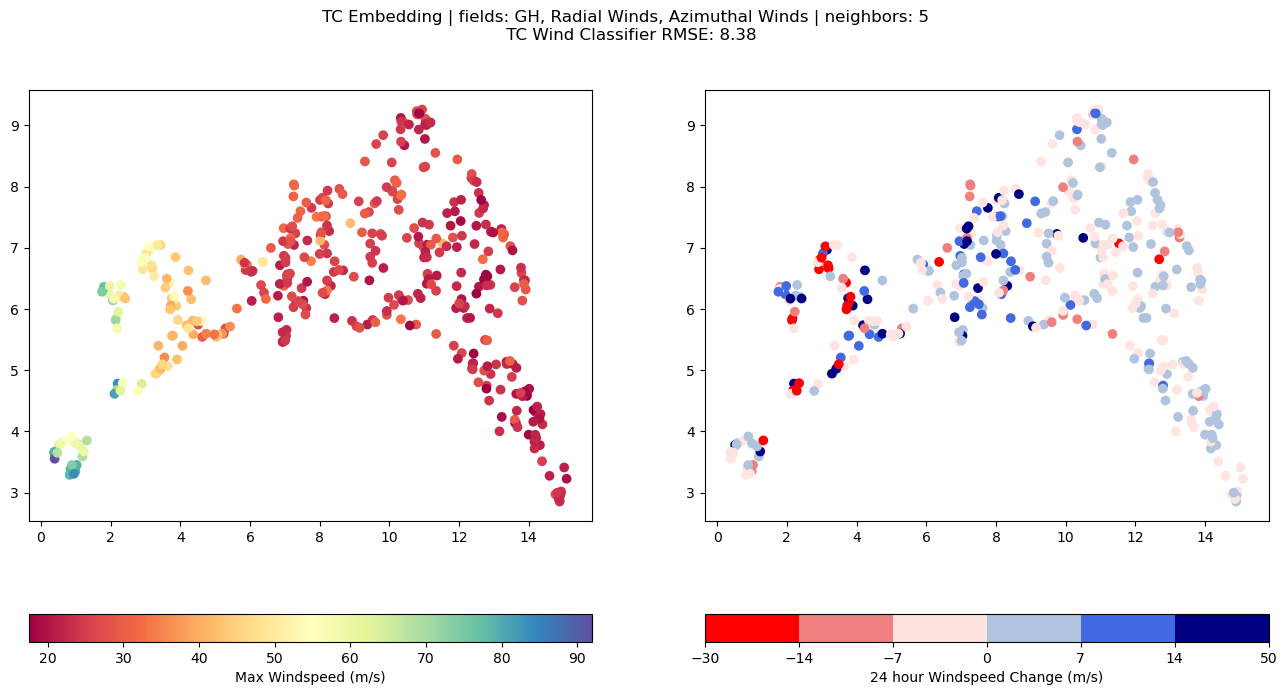

In [29]:

fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (16,8))
im_wind = axs[0].scatter(result_winds_gh[:,0], result_winds_gh[:,1], c = ds_final["max_wind"].isel(levels = 0).values, cmap = 'Spectral')
im_windchange = axs[1].scatter(result_winds_gh[:,0], result_winds_gh[:,1],  c = wind_change, cmap = wind_change_cmap, norm = wind_change_norm)
fig.colorbar(im_windchange, ax = axs[1], location = "bottom", label = "24 hour Windspeed Change (m/s)")
fig.colorbar(im_wind, ax = axs[0], location = "bottom", label = "Max Windspeed (m/s)")

fig.suptitle(f'TC Embedding | fields: GH, Radial Winds, Azimuthal Winds | neighbors: {NEIGHBORS} \n TC Wind Classifier RMSE: {np.round(result_winds_gh_lc['RMSE'],2)}')

Text(0.5, 0.98, 'TC Embedding | fields: Radial Winds, Azimuthal Winds | neighbors: 5  \n TC Wind Classifier RMSE: 9.94')

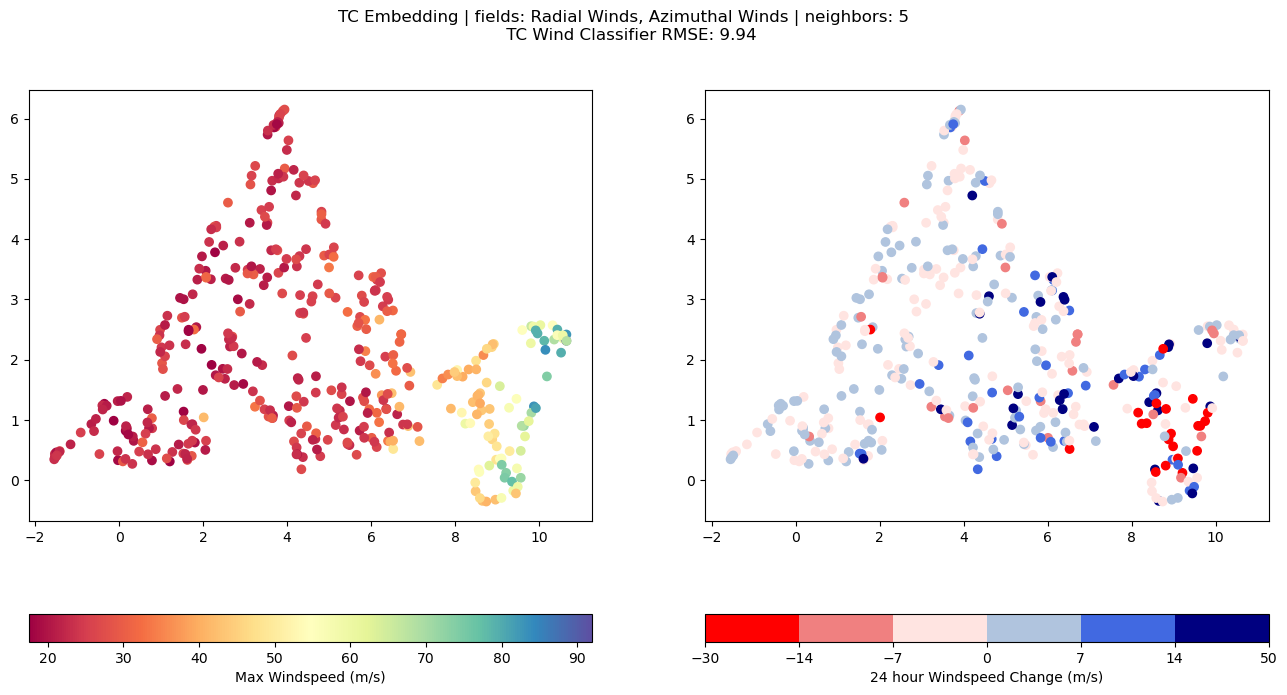

In [30]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (16,8))
im_wind = axs[0].scatter(result_winds[:,0], result_winds[:,1], c = ds_final["max_wind"].isel(levels = 0).values, cmap = 'Spectral')
im_windchange = axs[1].scatter(result_winds[:,0], result_winds[:,1],  c = wind_change, cmap = wind_change_cmap, norm = wind_change_norm)
fig.colorbar(im_windchange, ax = axs[1], location = "bottom", label = "24 hour Windspeed Change (m/s)")
fig.colorbar(im_wind, ax = axs[0], location = "bottom", label = "Max Windspeed (m/s)")

fig.suptitle(f'TC Embedding | fields: Radial Winds, Azimuthal Winds | neighbors: {NEIGHBORS}  \n TC Wind Classifier RMSE: {np.round(result_winds_lc['RMSE'],2)}')

Text(0.5, 0.98, 'TC Embedding | fields: GH | neighbors: 5 \n TC Wind Classifier RMSE: 7.64')

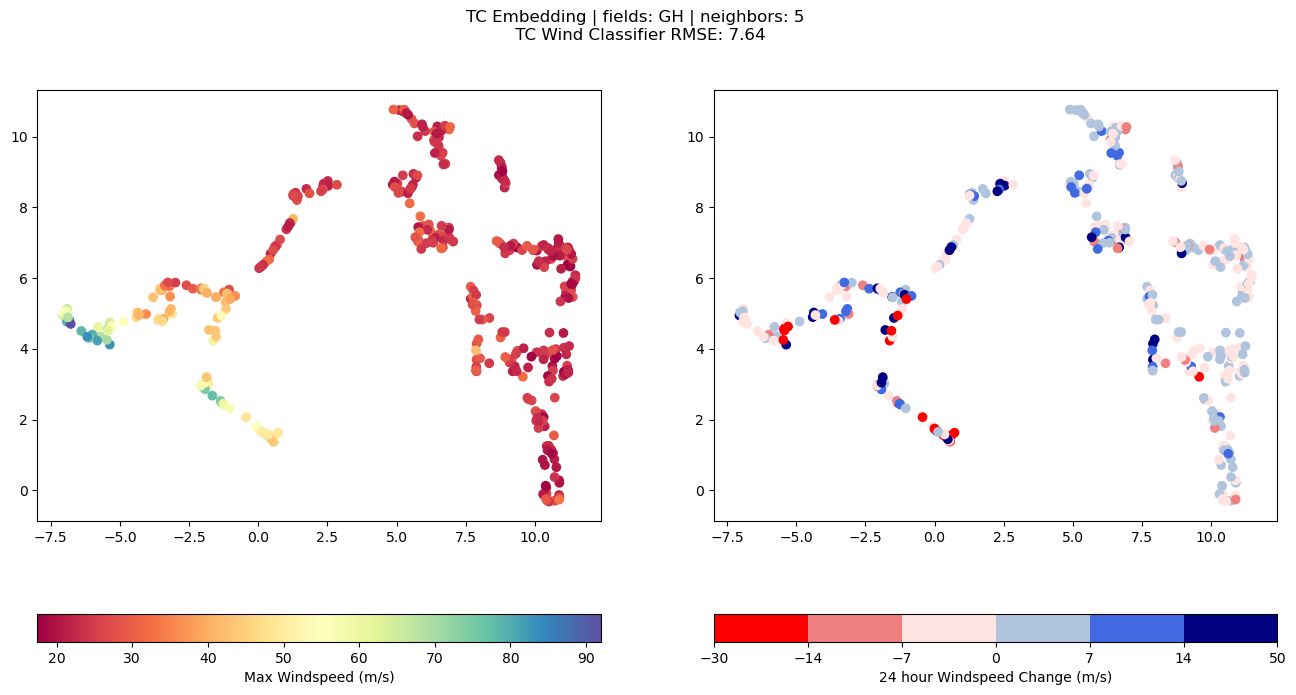

In [31]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (16,8))
im_wind = axs[0].scatter(result_gh[:,0], result_gh[:,1], c = ds_final["max_wind"].isel(levels = 0).values, cmap = 'Spectral')
im_windchange = axs[1].scatter(result_gh[:,0], result_gh[:,1],  c = wind_change, cmap = wind_change_cmap, norm = wind_change_norm)
fig.colorbar(im_windchange, ax = axs[1], location = "bottom", label = "24 hour Windspeed Change (m/s)")
fig.colorbar(im_wind, ax = axs[0], location = "bottom", label = "Max Windspeed (m/s)")

fig.suptitle(f'TC Embedding | fields: GH | neighbors: {NEIGHBORS} \n TC Wind Classifier RMSE: {np.round(result_gh_lc['RMSE'],2)}')

Text(0.5, 0.98, 'TC Baseline, fields: FL Max Wind, Minimum Central Pressure  \n TC Wind Classifier RMSE: 4.72')

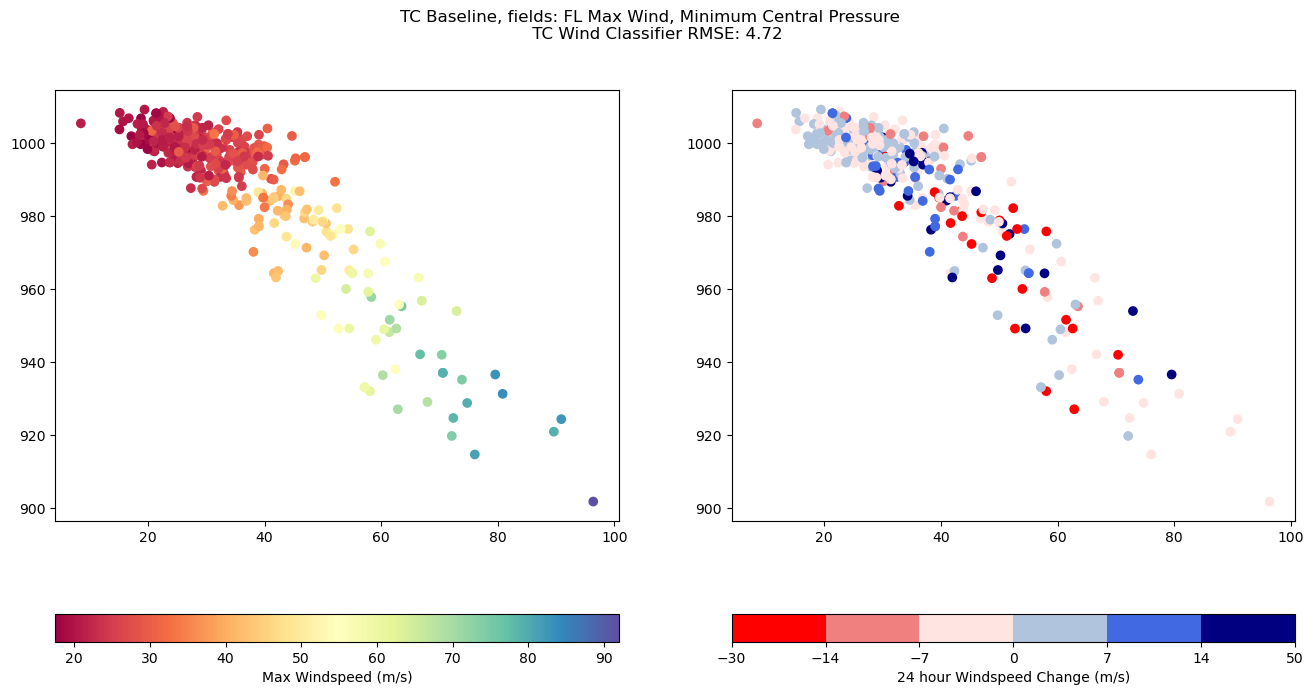

In [32]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (16,8))
im_wind = axs[0].scatter(fl_wind_max, ds_final['center_pressure'].isel(levels = 0).values, c = ds_final["max_wind"].isel(levels = 0).values, cmap = 'Spectral')
im_windchange = axs[1].scatter(fl_wind_max, ds_final['center_pressure'].isel(levels = 0).values,  c = wind_change, cmap = wind_change_cmap, norm = wind_change_norm)
fig.colorbar(im_windchange, ax = axs[1], location = "bottom", label = "24 hour Windspeed Change (m/s)")
fig.colorbar(im_wind, ax = axs[0], location = "bottom", label = "Max Windspeed (m/s)")

fig.suptitle(f'TC Baseline, fields: FL Max Wind, Minimum Central Pressure  \n TC Wind Classifier RMSE: {np.round(TC_baseline['RMSE'],2)}')

Creating Parametric UMAP Reductions

In [ ]:
# reducer3 = umap.UMAP(n_components = 2, n_neighbors = 3, random_state = 42, init = 'pca')
# embedding_composite_n3 = reducer3.fit_transform(combined_sfc700_gph_t)

pmap = umap.ParametricUMAP()
embedding_composite_pmap_full = pmap.fit_transform(combined_700)
embedding_composite_pmap_rad = pmap.fit_transform(rad_wind_700)
embedding_composite_pmap_az = pmap.fit_transform(az_wind_700)

# reducer15 = umap.UMAP(n_components = 2, n_neighbors = 15, random_state = 42, init = 'pca')
# embedding_composite_n15 = reducer15.fit_transform(combined_sfc700_gph_t)

# reducer10 = umap.UMAP(n_components = 2, n_neighbors = 10, random_state = 42, init = 'pca')
# embedding_composite_n10 = reducer10.fit_transform(combined_sfc700_gph_t)

# reducer20 = umap.UMAP(n_components = 2, n_neighbors = 20, random_state = 42, init = 'pca')
# embedding_composite_n20 = reducer20.fit_transform(combined_sfc700_gph_t)


Plotting UMAP compared to Minimum Central Pressure

In [ ]:
fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize = (14,20))

ax[0,0].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = max_winds, cmap = 'Spectral_r', s = 5)
ax[0,0].set_ylabel('GH, Azimuthal, and Radial Winds')
ax[0,0].set_title('Max Wind')

ax[1,0].scatter(embedding_az700_n5[:,0], embedding_az700_n5[:,1], c = max_winds, cmap = 'Spectral_r', s = 5)
ax[1,0].set_ylabel('Azimuthal Winds')

mslp_im = ax[2,0].scatter(embedding_rad700_n5[:,0], embedding_rad700_n5[:,1], c = max_winds, cmap = 'Spectral_r', s = 5)
ax[2,0].set_ylabel('Radial Winds')

fig.colorbar(mslp_im, ax = ax[2,0], location = 'bottom', label = 'Max Winds (m/s)')


ax[0,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[0,1].set_title('24 hr Wind Change')

ax[1,1].scatter(embedding_az700_n5[:,0], embedding_az700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

winds_im = ax[2,1].scatter(embedding_rad700_n5[:,0], embedding_rad700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)


# max_wind_im = ax[4,1].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(winds_im, ax = ax[2,1], location = 'bottom', label = 'Wind Change (m/s)')

# fig.suptitle('Comparison of UMAP reductions on HAFS Sfc RH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')
fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to Minimum Central Pressure', fontsize=16, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 5, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


Plotting UMAP Results Compare to Max Winds

In [ ]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (14,20))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface Fields')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = 'Maximum Windspeed (m/s)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,1].set_title('700mb Fields')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_RHsfc_n20[:,0], embedding_RHsfc_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(mslp_im, ax = ax[3,1], location = 'bottom', label = 'Maximum Windspeed (m/s)')

# fig.suptitle('Comparison of UMAP reductions on HAFS Sfc RH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')
fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to Maximum Windspeed', fontsize=16, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


Plotting UMAP Results Compare to Pressure Change 24hrs

In [ ]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (12,18))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = '24 Hour Pressure Change (mb)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)
ax[0,1].set_title('700mb')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)

max_wind_im = ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = pressure_change, cmap = 'RdBu_r', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[3,1], location = 'bottom', label = '24 Hour Pressure Change (mb)')

# fig.suptitle('Comparison of UMAP reductions on HAFS 700 GPH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to 24 Hour Pressure Change', fontsize=18, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


In [ ]:
fig, ax = plt.subplots(nrows = 4, ncols = 2, figsize = (14,20))

ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[0,0].set_ylabel('Geopotential Height')
ax[0,0].set_title('Surface')

ax[1,0].scatter(embedding_Tsfc_n5[:,0], embedding_Tsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[1,0].set_ylabel('Temperature')

ax[2,0].scatter(embedding_RHsfc_n5[:,0], embedding_RHsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[2,0].set_ylabel('Relative Humidity')

mslp_im = ax[3,0].scatter(embedding_Fullsfc_n5[:,0], embedding_Fullsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[3,0].set_ylabel('GPH, T, RH')

# mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(mslp_im, ax = ax[3,0], location = 'bottom', label = '24 Hour Maximum Windspeed Change (m/s)')

ax[0,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[0,1].set_title('700mb')

ax[1,1].scatter(embedding_T700_n5[:,0], embedding_T700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

ax[2,1].scatter(embedding_RH700_n5[:,0], embedding_RH700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

max_wind_im = ax[3,1].scatter(embedding_Full700_n5[:,0], embedding_Full700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(max_wind_im, ax = ax[3,1], location = 'bottom', label = '24 Hour Maximum Windspeed Change (m/s)')

# fig.suptitle('Comparison of UMAP reductions on HAFS 700 GPH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

fig.text(0.5, 0.91, 'Comparison of UMAP reductions on HAFS Model Output as compared to 24 Hour Maximum Windspeed Change', fontsize=18, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.90, "UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


In [ ]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (14,14))

sfc_ws_im = ax[0,0].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[0,0].set_ylabel('Surface')
ax[0,0].set_title('Max Windspeed Shading')

ax[1,0].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = max_winds, cmap = 'Spectral', s = 5)
ax[1,0].set_ylabel('700mb')



# mslp_im = ax[4,0].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = mslp, cmap = 'Spectral_r', s = 5)
# ax[4,0].set_ylabel('N Nearest Neighbors = 20')
fig.colorbar(sfc_ws_im, ax = ax[1,0], location = 'bottom', label = '24 Hour Maximum Windspeed Change (m/s)')

ax[0,1].scatter(embedding_GHsfc_n5[:,0], embedding_GHsfc_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)
ax[0,1].set_title('Max Windspeed Change Shading')

sfc_ws_change_im = ax[1,1].scatter(embedding_GH700_n5[:,0], embedding_GH700_n5[:,1], c = wind_change, cmap = 'RdBu', s = 5)

# max_wind_im = ax[4,1].scatter(embedding_GH700_n20[:,0], embedding_GH700_n20[:,1], c = max_winds, cmap = 'Spectral', s = 5)
fig.colorbar(sfc_ws_change_im, ax = ax[1,1], location = 'bottom', label = '24 Hour Maximum Windspeed Change (m/s)')

# fig.suptitle('Comparison of UMAP reductions on HAFS 700 GPH Model Output' \
#             '\n Data was filtered for winds over 17 m/s and Northern Hemisphere Storms.')

fig.suptitle( 'Comparison of UMAP reductions on HAFS Model Output as compared to 24 Hour Maximum Windspeed Change', fontsize=18, ha='center', transform=fig.transFigure)
# Subtitle on a new line
fig.text(0.5, 0.95, "UMAP Parameters: Init = PCA, Nearest Neighbors = 4, Random State = 12, DensMap = False, Data Normalization = MinMax Scaler", fontsize=10, ha='center', transform=fig.transFigure)


Computing Composites for two strengthening and two weakening clusters in the 700mb GPH

In [ ]:

filter_y = (embedding_GH700_n5[:,1] > 3) & (embedding_GH700_n5[:,1] < 4)
filter_x = (embedding_GH700_n5[:,0] > -5) & (embedding_GH700_n5[:,0] < -3)
cluster1_filter = filter_x * filter_y

filter_y = (embedding_GH700_n5[:,1] > 2) & (embedding_GH700_n5[:,1] < 4)
filter_x = (embedding_GH700_n5[:,0] > 7) & (embedding_GH700_n5[:,0] < 10)
cluster2_filter = filter_x * filter_y

filter_y = (embedding_GH700_n5[:,1] > 1) & (embedding_GH700_n5[:,1] < 2)
filter_x = (embedding_GH700_n5[:,0] > -1) & (embedding_GH700_n5[:,0] < 0.2)
cluster3_filter = filter_x * filter_y

filter_y = (embedding_GH700_n5[:,1] > 5.2) & (embedding_GH700_n5[:,1] < 6.2)
filter_x = (embedding_GH700_n5[:,0] > 0) & (embedding_GH700_n5[:,0] < 2)
cluster4_filter = filter_x * filter_y

In [ ]:
UMAP_embedding = embedding_GH700_n5
composite_filter = cluster4_filter
cluster_wind_change = wind_change[composite_filter]
plt.scatter(UMAP_embedding[:,0], UMAP_embedding[:,1],color = 'black', s = 5, alpha = 0.05)
plt.scatter(UMAP_embedding[composite_filter,0], UMAP_embedding[composite_filter,1], 
            cmap = 'Spectral', c = cluster_wind_change, s = 5,
            vmin = windspeed_min,
            vmax = windspeed_max)

In [ ]:
cluster1_wind_change = wind_change[cluster1_filter]
avg_cluster1_wind_change = np.nanmean(cluster1_wind_change)
cluster1_winds = max_winds[cluster1_filter]
avg_cluster1_wind = np.nanmean(cluster1_winds)
med_cluster1_wind = np.nanmedian(cluster1_winds)
cluster1_size = len(cluster1_winds)

cluster2_wind_change = wind_change[cluster2_filter]
avg_cluster2_wind_change = np.nanmean(cluster2_wind_change)
cluster2_winds = max_winds[cluster2_filter]
avg_cluster2_wind = np.nanmean(cluster2_winds)
med_cluster2_wind = np.nanmedian(cluster2_winds)
cluster2_size = len(cluster2_winds)

cluster3_wind_change = wind_change[cluster3_filter]
avg_cluster3_wind_change = np.nanmean(cluster3_wind_change)
cluster3_winds = max_winds[cluster3_filter]
avg_cluster3_wind = np.nanmean(cluster3_winds)
med_cluster3_wind = np.nanmedian(cluster3_winds)
cluster3_size = len(cluster3_winds)

cluster4_wind_change = wind_change[cluster4_filter]
avg_cluster4_wind_change = np.nanmean(cluster4_wind_change)
cluster4_winds = max_winds[cluster4_filter]
avg_cluster4_wind = np.nanmean(cluster4_winds)
med_cluster4_wind = np.nanmedian(cluster4_winds)
cluster4_size = len(cluster4_winds)

wind_change_min = np.min(wind_change)
wind_change_max = np.max(wind_change)
windspeed_min = np.min(max_winds)
windspeed_max = np.max(max_winds)

In [ ]:
cluster4_size

In [ ]:
med_cluster1_wind

In [ ]:
def get_CI(field_anomalies, filter):
    n_samples = 1000

    cluster_size = np.sum(filter)
    cluster_mean = np.mean(field_anomalies[filter,:,:])
    bootstrap_anomalies = []
    for n in range(n_samples):
            indices = np.random.choice(field_anomalies.shape[0], size = cluster_size, replace = True)
            sample_fields = field_anomalies[indices, :, :]
            mean_sample = np.mean(sample_fields, axis = 0)
            bootstrap_anomalies.append(cluster_mean - mean_sample)
            
 
    
    ci_lo = np.quantile(bootstrap_anomalies, 0.025, axis = 0)
    ci_hi = np.quantile(bootstrap_anomalies, 0.975, axis = 0)
    p_value = np.mean(np.array(bootstrap_anomalies) <= 0)
        

    return (ci_lo,ci_hi), p_value  
    # significantU = np.zeros([field_anomalies.shape[1], field_anomalies.shape[2]])
    # significantL = np.zeros([field_anomalies.shape[1], field_anomalies.shape[2]])
    # significantU[cluster_field_mean_anomaly > upper95] = True
    # significantL[cluster_field_mean_anomaly < lower05] = True

    # significant_areas = significantL + significantU
    # significant_areas_coords = np.where(significant_areas == 1)
    # sig_coords_radius = []

In [ ]:
def difference_of_means(data1, data2, axis):
    return np.mean(data1, axis = axis) - np.mean(data2, axis = axis)

level = 1
composite_filter = cluster4_filter

angle = ds_cleaned.angle.values
radius = ds_cleaned.radius.values

ds_gph = ds_cleaned['gh'].isel(levels = level).values
ds_t = ds_cleaned['t'].isel(levels = level).values
max_winds = ds_cleaned['max_wind'].values[:,0]
wind_change = ds_cleaned['24HrMaxWinds'].isel(levels = 0).values - max_winds

cluster_wind_change = wind_change[composite_filter]
avg_cluster_wind_change = np.nanmean(cluster_wind_change)
cluster_winds = max_winds[composite_filter]
avg_cluster_wind = np.nanmean(cluster_winds)
cluster_size =np.sum(composite_filter)
#### GH Composite ####
mean_field_gh = np.mean(ds_gph, axis = 0)
field_anomalies_gh = ds_gph - mean_field_gh
cluster_field_anomalies_gh = field_anomalies_gh[composite_filter, :, :]
cluster_field_mean_anom_gh = np.mean(cluster_field_anomalies_gh, axis = 0)
cluster_field_mean_gh = np.mean(ds_gph[composite_filter,:,:], axis = 0)

CI_gh, pvalue_gh = get_CI(field_anomalies_gh, composite_filter)
            
sig_gh_x, sig_gh_y = np.where(np.logical_or((CI_gh[0] > 0), ( CI_gh[1] < 0)))
sig_gh_x = sig_gh_x/2
sig_gh_y = sig_gh_y/2
# sig_upper_gh = np.where(CI_gh_hi < np.quantile(cluster_field_anomalies_gh, .025, axis = 0))
# sig_upper_x_gh = sig_upper_gh[0]/2
# sig_upper_y_gh = sig_upper_gh[1]/2

# sig_lower_gh = np.where(CI_gh_lo > np.quantile(cluster_field_anomalies_gh, .975, axis = 0))
# sig_lower_x_gh = sig_lower_gh[0]/2
# sig_lower_y_gh = sig_lower_gh[1]/2

#### T Composite #####
mean_field_t = np.mean(ds_t, axis = 0)
field_anomalies_t = ds_t - mean_field_t
cluster_field_anomalies_t = field_anomalies_t[composite_filter, :, :]
cluster_field_mean_anom_t = np.mean(cluster_field_anomalies_t, axis = 0)
cluster_field_mean_t = np.mean(ds_t[composite_filter,:,:], axis = 0)

CI_t, pvalue_t = get_CI(field_anomalies_t, composite_filter)

# sig_upper_t = np.where(CI_t_hi < np.quantile(cluster_field_anomalies_t, .025, axis = 0))
# sig_upper_x_t = sig_upper_t[0]/2
# sig_upper_y_t = sig_upper_t[1]/2

# sig_lower_t = np.where(CI_t_lo > np.quantile(cluster_field_anomalies_t, .975, axis = 0))
# sig_lower_x_t = sig_lower_t[0]/2
# sig_lower_y_t = sig_lower_t[1]/2

sig_t_x, sig_t_y = np.where(np.logical_or((CI_t[0] > 0), ( CI_t[1] < 0)))
sig_t_x = sig_t_x/2
sig_t_y = sig_t_y/2

# fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(12, 12), subplot_kw= {'projection':'polar'})
# Theta, R = np.meshgrid(angle, radius)
# height_im = ax[0].pcolormesh(angle, radius, cluster_field_anomalies_gh, cmap = 'RdBu', shading = 'nearest')
# ax[0].scatter(sig_upper_x_gh, sig_upper_y_gh, alpha = 0.01, color = 'black', marker = 'x', s = 1)
# ax[0].grid(False)
# ax[0].set_theta_direction(-1)
# ax[0].set_theta_offset(np.pi/2)
    # ax[0].text(5.48,450, f'24hr Mean Max Wind Change: {avg_cluster_wind_change:.2f} m/s')
    # ax[0].set_title('Geopotential Height')
    # ax00_inset = ax[0].inset_axes([.8, .65, .5, .4])
    # ax00_inset.scatter(UMAP_embedding[:,0], UMAP_embedding[:,1],color = 'black', s = 5, alpha = 0.05)
    # ax00_inset.scatter(UMAP_embedding[filter,0], UMAP_embedding[filter,1], 
    #                c = cluster_winds, cmap = 'Spectral', s = 5,
    #                vmin = windspeed_min,
    #                vmax = windspeed_max)
    # fig.colorbar(height_im,cax = ax[0], location = 'bottom')

In [ ]:
UMAP_embedding = embedding_GH700_n5

cluster_name = 'Cluster 4'
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(12, 12), subplot_kw= {'projection':'polar'})
Theta, R = np.meshgrid(angle, radius)
height_im = ax[0,0].contourf(angle, radius, cluster_field_mean_gh.T, cmap = 'RdBu_r')
# ax[0,0].scatter(sig_upper_x_gh[::50], sig_upper_y_gh[::50], alpha = 0.1, color = 'black', marker = 'x', s = 10)
# ax[0,0].scatter(sig_lower_x_gh[::50], sig_lower_y_gh[::50], alpha = 0.1, color = 'black', marker = 'x', s = 10)
ax[0,0].grid(False)
ax[0,0].set_theta_direction(-1)
ax[0,0].set_theta_offset(np.pi/2)
ax[0,0].set_title('Cluster Geopotential Height')
fig.colorbar(height_im, ax = ax[0,0], location = 'bottom', label = 'Geopotential Height (m)')

temp_im = ax[0,1].contourf(angle, radius, cluster_field_mean_t.T, cmap = 'viridis')
# ax[0,1].scatter(sig_upper_x_t[::60], sig_upper_y_t[::60], alpha = 0.15, color = 'black', marker = '*', s = 5)
# ax[0,1].scatter(sig_lower_x_t[::60], sig_lower_y_t[::60], alpha = 0.15, color = 'black', marker = '*', s = 5)
ax[0,1].grid(False)
ax[0,1].set_theta_direction(-1)
ax[0,1].set_theta_offset(np.pi/2)
ax[0,1].set_title('Cluster Temperature')
fig.colorbar(temp_im, ax = ax[0,1], location = 'bottom', label = 'Temperature (C)')

ax00_inset = ax[0,0].inset_axes([1.15, .66, .5, .4])
ax00_inset.scatter(UMAP_embedding[:,0], UMAP_embedding[:,1],color = 'black', s = 5, alpha = 0.05)
ax00_inset.scatter(UMAP_embedding[composite_filter,0], UMAP_embedding[composite_filter,1], 
                   c = cluster_winds, cmap = 'Spectral', s = 5,
                   vmin = windspeed_min,
                   vmax = windspeed_max)


height_anom_im = ax[1,0].contourf(angle, radius, cluster_field_mean_anom_gh.T, cmap = 'RdBu_r')
# ax[1,0].scatter(sig_gh_x[::30], sig_gh_y[::30], alpha = 0.1, color = 'black', marker = 'x', s = 10)
# ax[1,0].scatter(sig_lower_x_gh[::40], sig_lower_y_gh[::40], alpha = 0.1, color = 'black', marker = 'x', s = 10)
ax[1,0].grid(False)
ax[1,0].set_theta_direction(-1)
ax[1,0].set_theta_offset(np.pi/2)
ax[1,0].set_title('Cluster Geopotential Height Anomaly')
fig.colorbar(height_anom_im, ax = ax[1,0], location = 'bottom', label = 'Geopotential Height Anomaly (m)')

temp_anom_im = ax[1,1].contourf(angle, radius, cluster_field_mean_anom_t.T, cmap = 'viridis')
# ax[1,1].scatter(sig_t_x[::20], sig_t_y[::20], alpha = 0.05, color = 'black', marker = '*', s = 1)
# ax[1,1].scatter(sig_lower_x_t, sig_lower_y_t, alpha = 0.05, color = 'black', marker = '*', s = 1)
ax[1,1].grid(False)
ax[1,1].set_theta_direction(-1)
ax[1,1].set_theta_offset(np.pi/2)
ax[1,1].set_title('Cluster Temperature Anomaly')
fig.colorbar(temp_anom_im, ax = ax[1,1], location = 'bottom', label = 'Temperature Anomaly (C)')

fig.suptitle(f'{cluster_name} \nCluster Average Windspeed: {avg_cluster_wind:.2f} m/s \nCluster Average 24hr Storm Intensity Change: {avg_cluster_wind_change:.2f} m/s \n Cluster Size: {cluster_size}')

In [ ]:
lats1 = ds_cleaned['center_lat'].isel(levels = 0).values[cluster1_filter]
lons1 = ds_cleaned['center_lon'].isel(levels = 0).values[cluster1_filter]
lats2 = ds_cleaned['center_lat'].isel(levels = 0).values[cluster2_filter]
lons2 = ds_cleaned['center_lon'].isel(levels = 0).values[cluster2_filter]
lats3 = ds_cleaned['center_lat'].isel(levels = 0).values[cluster3_filter]
lons3 = ds_cleaned['center_lon'].isel(levels = 0).values[cluster3_filter]
lats4 = ds_cleaned['center_lat'].isel(levels = 0).values[cluster4_filter]
lons4 = ds_cleaned['center_lon'].isel(levels = 0).values[cluster4_filter]


fig, ax = plt.subplots(nrows = 4, ncols = 1, figsize = (10,8), subplot_kw = {'projection': ccrs.PlateCarree()})

ax[0].scatter(lons1, lats1, transform = ccrs.PlateCarree(), s = 3)
ax[0].add_feature(CFeature.COASTLINE)

ax[0].set_title('Cluster 1')

ax[1].scatter(lons2, lats2, transform = ccrs.PlateCarree(), s = 3)
ax[1].add_feature(CFeature.COASTLINE)
ax[1].set_title('Cluster 2')

ax[2].scatter(lons3, lats3, transform = ccrs.PlateCarree(), s = 3)
ax[2].add_feature(CFeature.COASTLINE)
ax[2].set_title('Cluster 3')

ax[3].scatter(lons4, lats4, transform = ccrs.PlateCarree(), s = 3)
ax[3].add_feature(CFeature.COASTLINE)
ax[3].set_title('Cluster 4')

fig.suptitle('Storm Locations by Cluster')


Computing composites for both clusters the 700mb GPH, T, RH combined cluster

In [ ]:
filter_y = embedding_Full700_n5[:,1] > 5
filter_x = embedding_Full700_n5[:,0] < 0
cluster1_filter_700mbFull = filter_x * filter_y

filter_y = embedding_Full700_n5[:,1] < 6
filter_x = embedding_Full700_n5[:,0] > 10
cluster2_filter_700mbFull = filter_x * filter_y

cluster1_wind_change = wind_change[cluster1_filter_700mbFull]
cluster2_wind_change = wind_change[cluster2_filter_700mbFull]

